# SUP ML 2 - MODEL

# Libraries

In [ ]:
import warnings
warnings.simplefilter(action = 'ignore', category = FutureWarning)

# imports best practice pandas
import os

import numpy as np
import pandas as pd
import missingno as msno
import plotly.express as px
import matplotlib.pyplot as plt
import seaborn as sns
import pickle

#--------------------------------------------------------
# imports best practice sklearn
import sklearn
from sklearn.feature_selection import VarianceThreshold
from sklearn import set_config

from sklearn.tree import DecisionTreeClassifier

# preprocessing
from sklearn.preprocessing import StandardScaler, PolynomialFeatures
from sklearn.feature_selection import VarianceThreshold
from sklearn.preprocessing import StandardScaler, OrdinalEncoder, OneHotEncoder
from scipy import stats

# transformers
from sklearn.impute import SimpleImputer

# evaluacion
from sklearn.metrics import mean_absolute_error, r2_score, roc_curve, confusion_matrix, ConfusionMatrixDisplay, accuracy_score, precision_score, recall_score, f1_score
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn import metrics

#interpretabilidad
!pip install shap
import shap

# modelos
from sklearn.model_selection import cross_val_score
from sklearn.metrics import roc_auc_score
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.ensemble import AdaBoostClassifier
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.ensemble import BaggingClassifier
from sklearn.neural_network import MLPClassifier
from sklearn.gaussian_process import GaussianProcessClassifier
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier

# pipelines
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
set_config(transform_output = "pandas")

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 533.5/533.5 kB 2.6 MB/s eta 0:00:00


# Carga clean data

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
CWD = os.getcwd()

DATA_PATH = os.path.join(CWD, "/content/drive/MyDrive/EJERCICIO-ML-Sup/data")

df_telecom_clean = pd.read_pickle(os.path.join(DATA_PATH, "dataset_clean"))

In [ ]:
df_telecom_clean.head()

,oe_cat_1__categorical_impute_1__new_cell_N,oe_cat_1__categorical_impute_1__new_cell_U,oe_cat_1__categorical_impute_1__new_cell_Y,oe_cat_1__categorical_impute_1__crclscod_A,oe_cat_1__categorical_impute_1__crclscod_A2,oe_cat_1__categorical_impute_1__crclscod_AA,oe_cat_1__categorical_impute_1__crclscod_B,oe_cat_1__categorical_impute_1__crclscod_BA,oe_cat_1__categorical_impute_1__crclscod_C,oe_cat_1__categorical_impute_1__crclscod_CA,...,remainder__numeric_impute__avg6qty,remainder__numeric_impute__avg6rev,remainder__numeric_impute__hnd_price,remainder__numeric_impute__phones,remainder__numeric_impute__lor,remainder__numeric_impute__adults,remainder__numeric_impute__income,remainder__numeric_impute__numbcars,remainder__numeric_impute__eqpdays,remainder__remainder__churn
Customer_ID,,,,,,,,,,,,,,,,,,,,,
1000001,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,...,136.0,38.0,149.98999,2.0,15.0,1.0,4.0,3.0,361.0,1
1000002,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,275.0,48.0,-999.00000,7.0,1.0,1.0,5.0,1.0,240.0,0
1000003,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,...,6.0,17.0,29.98999,2.0,7.0,2.0,5.0,2.0,1504.0,1
1000004,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,...,25.0,40.0,29.98999,1.0,6.0,4.0,6.0,1.0,1812.0,0
1000005,0.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,...,196.0,80.0,149.98999,6.0,5.0,1.0,6.0,1.0,434.0,0


In [ ]:
df_telecom_clean.info(verbose=True, show_counts=True)

<class 'pandas.core.frame.DataFrame'>
Int64Index: 90000 entries, 1000001 to 1090000
Data columns (total 158 columns):
 #    Column                                                              Non-Null Count  Dtype  
---   ------                                                              --------------  -----  
 0    oe_cat_1__categorical_impute_1__new_cell_N                          90000 non-null  float64
 1    oe_cat_1__categorical_impute_1__new_cell_U                          90000 non-null  float64
 2    oe_cat_1__categorical_impute_1__new_cell_Y                          90000 non-null  float64
 3    oe_cat_1__categorical_impute_1__crclscod_A                          90000 non-null  float64
 4    oe_cat_1__categorical_impute_1__crclscod_A2                         90000 non-null  float64
 5    oe_cat_1__categorical_impute_1__crclscod_AA                         90000 non-null  float64
 6    oe_cat_1__categorical_impute_1__crclscod_B                          90000 non-null  float64


# Split X-y

In [ ]:
target = 'remainder__remainder__churn'
features = df_telecom_clean.columns[df_telecom_clean.columns!=target]

# Divide dataset en matriz de variables (X) y output (y)
X = df_telecom_clean[features]
y = df_telecom_clean[target]

# Distribución del target

In [ ]:
pd.Series(y).value_counts() / len(y)

1    0.508889
0    0.491111
Name: remainder__remainder__churn, dtype: float64

# Undersampling (*)

**NOTA:** SOLO EN CLASIFICACIÓN cuando el ratio de éxitos está MUY DESBALANCEADO (<10%).

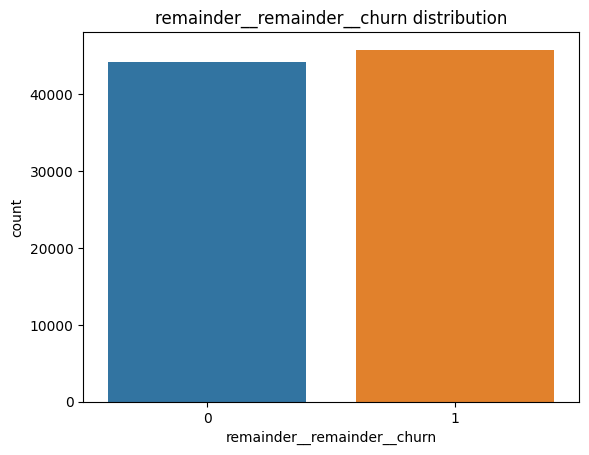

In [ ]:
sns.countplot(x=y)
plt.title(target+' distribution')
plt.show()

# Split TRAIN-TEST

In [ ]:
# Divide X-y en Train (80%) y Test (20%)
# RANDOM HOLDOUT (shuffle = True)

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20, shuffle=True, random_state=42)

In [ ]:
print('Train set size:',X_train.shape[0])
print('Test set size:',X_test.shape[0])

Train set size: 72000
Test set size: 18000


In [ ]:
X_train.head(3)

,oe_cat_1__categorical_impute_1__new_cell_N,oe_cat_1__categorical_impute_1__new_cell_U,oe_cat_1__categorical_impute_1__new_cell_Y,oe_cat_1__categorical_impute_1__crclscod_A,oe_cat_1__categorical_impute_1__crclscod_A2,oe_cat_1__categorical_impute_1__crclscod_AA,oe_cat_1__categorical_impute_1__crclscod_B,oe_cat_1__categorical_impute_1__crclscod_BA,oe_cat_1__categorical_impute_1__crclscod_C,oe_cat_1__categorical_impute_1__crclscod_CA,...,remainder__numeric_impute__avg6mou,remainder__numeric_impute__avg6qty,remainder__numeric_impute__avg6rev,remainder__numeric_impute__hnd_price,remainder__numeric_impute__phones,remainder__numeric_impute__lor,remainder__numeric_impute__adults,remainder__numeric_impute__income,remainder__numeric_impute__numbcars,remainder__numeric_impute__eqpdays
Customer_ID,,,,,,,,,,,,,,,,,,,,,
1051005,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,...,440.0,134.0,53.0,149.98999,1.0,-999.0,1.0,6.0,1.0,383.0
1011454,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,2253.0,1032.0,94.0,29.98999,10.0,-999.0,-999.0,-999.0,-999.0,48.0
1009692,0.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,...,96.0,63.0,61.0,29.98999,1.0,10.0,4.0,7.0,2.0,881.0


In [ ]:
X_test.head(3)

,oe_cat_1__categorical_impute_1__new_cell_N,oe_cat_1__categorical_impute_1__new_cell_U,oe_cat_1__categorical_impute_1__new_cell_Y,oe_cat_1__categorical_impute_1__crclscod_A,oe_cat_1__categorical_impute_1__crclscod_A2,oe_cat_1__categorical_impute_1__crclscod_AA,oe_cat_1__categorical_impute_1__crclscod_B,oe_cat_1__categorical_impute_1__crclscod_BA,oe_cat_1__categorical_impute_1__crclscod_C,oe_cat_1__categorical_impute_1__crclscod_CA,...,remainder__numeric_impute__avg6mou,remainder__numeric_impute__avg6qty,remainder__numeric_impute__avg6rev,remainder__numeric_impute__hnd_price,remainder__numeric_impute__phones,remainder__numeric_impute__lor,remainder__numeric_impute__adults,remainder__numeric_impute__income,remainder__numeric_impute__numbcars,remainder__numeric_impute__eqpdays
Customer_ID,,,,,,,,,,,,,,,,,,,,,
1089611,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,...,494.0,209.0,89.0,129.98999,1.0,-999.0,-999.0,-999.0,-999.0,326.0
1012457,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,...,200.0,106.0,38.0,29.98999,2.0,6.0,2.0,9.0,1.0,186.0
1053404,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,...,390.0,165.0,54.0,149.98999,1.0,1.0,3.0,1.0,-999.0,362.0


# Rescaling

* NO NECESARIO en modelos de Arboles de Decisión.
* Guardar scaler en el model path.

In [ ]:
# no hacemos rescaling

# TRAIN-VALIDA

## Torneo de Modelos

* Probamos una colección de modelos con el objetivo de conseguir el mejor rendimiento del modelo en los datos de VALIDACION.

In [ ]:
# Funcion que calcula el AUC de un modelo sobre un dataset (X-y). Args: modelo a validar, X, y
def auc(model,X,y):
  model.fit(X,y)
  return roc_auc_score(y,model.predict_proba(X)[:,1])

# Funcion que calcula el AUC en Cross-Validation (X-y). Args: modelo a validar, X, y
def auc_cross_validation(model,X,y):
  cross_val = cross_val_score(model,
                              X, y,
                              cv=4,                 # Numero de folds que vamos a utilizar para validar
                              scoring='roc_auc'     # La metrica de validacion que se medira en cada train-valida
                              )
  return cross_val.mean()

In [ ]:
# Inicializa resultados
label_, auc_train_ , auc_valida_ = [], [], []

# Completa un registro en dataframe con los resultados de las funciones definidas previsamente ( AUC y AUC con cross-validation)

# Inputs:
#   * modelo
#   * (X,y)
#   * label especifico si queremos registrar el resultado con otro nombre (opcional)


def evaluate_classification(model, X, y, label=None):
  if label is None:
    label=str(model)
  label_.append(label)

  auc_train = auc(model,X,y)
  auc_valida = auc_cross_validation(model,X,y)
  auc_train_.append(auc_train)
  auc_valida_.append(auc_valida)

  return pd.DataFrame({'Model': label_,
                      'AUC Train': auc_train_,
                      'AUC Cross-Valida': auc_valida_
                      }).sort_values('AUC Cross-Valida',ascending=False)

In [ ]:
evaluate_classification(model = LogisticRegression(), X=X_train, y=y_train)

lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the doc

,Model,AUC Train,AUC Cross-Valida
0,LogisticRegression(),0.600304,0.599191


In [ ]:
evaluate_classification(model = RandomForestClassifier(), X=X_train, y=y_train)


,Model,AUC Train,AUC Cross-Valida
1,RandomForestClassifier(),1.000000,0.658921
0,LogisticRegression(),0.600304,0.599191


In [ ]:
evaluate_classification(model = XGBClassifier(), X=X_train, y=y_train)

,Model,AUC Train,AUC Cross-Valida
2,"XGBClassifier(base_score=None, booster=None, c...",0.851763,0.670506
1,RandomForestClassifier(),1.000000,0.658921
0,LogisticRegression(),0.600304,0.599191


In [ ]:
evaluate_classification(model = LGBMClassifier(), X=X_train, y=y_train)

[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] Number of positive: 36634, number of negative: 35366
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.159412 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 11451
[LightGBM] [Info] Number of data points in the train set: 72000, number of used features: 157
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.508806 -> initscore=0.035226
[LightGBM] [Info] Start training from score 0.035226
[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] Number of positive: 27476, number of negative: 26524
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.030940 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 11349
[LightGBM] [In

,Model,AUC Train,AUC Cross-Valida
3,LGBMClassifier(),0.750649,0.682622
2,"XGBClassifier(base_score=None, booster=None, c...",0.851763,0.670506
1,RandomForestClassifier(),1.000000,0.658921
0,LogisticRegression(),0.600304,0.599191


In [ ]:
evaluate_classification(model = AdaBoostClassifier(), X=X_train, y=y_train)

,Model,AUC Train,AUC Cross-Valida
3,LGBMClassifier(),0.750649,0.682622
2,"XGBClassifier(base_score=None, booster=None, c...",0.851763,0.670506
1,RandomForestClassifier(),1.000000,0.658921
4,AdaBoostClassifier(),0.666366,0.658796
0,LogisticRegression(),0.600304,0.599191


In [ ]:
evaluate_classification(model = GradientBoostingClassifier(), X=X_train, y=y_train)

,Model,AUC Train,AUC Cross-Valida
3,LGBMClassifier(),0.750649,0.682622
5,GradientBoostingClassifier(),0.690072,0.672471
2,"XGBClassifier(base_score=None, booster=None, c...",0.851763,0.670506
1,RandomForestClassifier(),1.000000,0.658921
4,AdaBoostClassifier(),0.666366,0.658796
0,LogisticRegression(),0.600304,0.599191


In [ ]:
evaluate_classification(model = DecisionTreeClassifier(), X=X_train, y=y_train)

,Model,AUC Train,AUC Cross-Valida
3,LGBMClassifier(),0.750649,0.682622
5,GradientBoostingClassifier(),0.690072,0.672471
2,"XGBClassifier(base_score=None, booster=None, c...",0.851763,0.670506
1,RandomForestClassifier(),1.000000,0.658921
4,AdaBoostClassifier(),0.666366,0.658796
0,LogisticRegression(),0.600304,0.599191
6,DecisionTreeClassifier(),1.000000,0.546388


In [ ]:
evaluate_classification(model = MLPClassifier(), X=X_train, y=y_train)

,Model,AUC Train,AUC Cross-Valida
3,LGBMClassifier(),0.750649,0.682622
5,GradientBoostingClassifier(),0.690072,0.672471
2,"XGBClassifier(base_score=None, booster=None, c...",0.851763,0.670506
1,RandomForestClassifier(),1.000000,0.658921
4,AdaBoostClassifier(),0.666366,0.658796
0,LogisticRegression(),0.600304,0.599191
7,MLPClassifier(),0.561003,0.589528
6,DecisionTreeClassifier(),1.000000,0.546388


In [ ]:
evaluate_classification(model = BaggingClassifier(), X=X_train, y=y_train)

,Model,AUC Train,AUC Cross-Valida
3,LGBMClassifier(),0.750649,0.682622
5,GradientBoostingClassifier(),0.690072,0.672471
2,"XGBClassifier(base_score=None, booster=None, c...",0.851763,0.670506
1,RandomForestClassifier(),1.000000,0.658921
4,AdaBoostClassifier(),0.666366,0.658796
8,BaggingClassifier(),0.999007,0.613613
0,LogisticRegression(),0.600304,0.599191
7,MLPClassifier(),0.561003,0.589528
6,DecisionTreeClassifier(),1.000000,0.546388


## Hiperparametrizacion

* Utilizar RandomSearch para probar diferentes configuraciones de los parametros del modelo ganador en el torneo de modelos con el objetivo de mejorar el control del overfitting.

In [ ]:
from sklearn.model_selection import RandomizedSearchCV

In [ ]:
help(LGBMClassifier)

Help on class LGBMClassifier in module lightgbm.sklearn:

class LGBMClassifier(sklearn.base.ClassifierMixin, LGBMModel)
 |  LGBMClassifier(boosting_type: str = 'gbdt', num_leaves: int = 31, max_depth: int = -1, learning_rate: float = 0.1, n_estimators: int = 100, subsample_for_bin: int = 200000, objective: Union[str, Callable[[Optional[numpy.ndarray], numpy.ndarray], Tuple[numpy.ndarray, numpy.ndarray]], Callable[[Optional[numpy.ndarray], numpy.ndarray, Optional[numpy.ndarray]], Tuple[numpy.ndarray, numpy.ndarray]], Callable[[Optional[numpy.ndarray], numpy.ndarray, Optional[numpy.ndarray], Optional[numpy.ndarray]], Tuple[numpy.ndarray, numpy.ndarray]], NoneType] = None, class_weight: Union[Dict, str, NoneType] = None, min_split_gain: float = 0.0, min_child_weight: float = 0.001, min_child_samples: int = 20, subsample: float = 1.0, subsample_freq: int = 0, colsample_bytree: float = 1.0, reg_alpha: float = 0.0, reg_lambda: float = 0.0, random_state: Union[int, numpy.random.mtrand.RandomS

In [ ]:
parametros = {'boosting_type':['gbdt','rf','dart'],
              'num_leaves':[10,20,30,40,50,60,70],
              'max_depth':[1,2,4,6,8,10,12,14],
              'learning_rate':[0.1,0.2,0.4,0.6,0.8],
              'n_estimators':[100,200,300,400,500,600,700,800]
}

In [ ]:
search_hp = RandomizedSearchCV(estimator=LGBMClassifier(),
                               param_distributions = parametros,
                               scoring='roc_auc',     # metrica a optimizar: roc_auc
                               cv = 4,            # numero de folds para cross-validation
                               n_iter = 20,       # numero de iteraciones, cada una testeara una configuracion distinta
                               n_jobs=-1,
                               verbose=True)

In [29]:
search_hp.fit(X_train, y_train)

Fitting 4 folds for each of 20 candidates, totalling 80 fits



32 fits failed out of a total of 80.
The score on these train-test partitions for these parameters will be set to nan.
If these failures are not expected, you can try to debug them by setting error_score='raise'.

Below are more details about the failures:
--------------------------------------------------------------------------------
32 fits failed with the following error:
Traceback (most recent call last):
  File "/usr/local/lib/python3.10/dist-packages/sklearn/model_selection/_validation.py", line 686, in _fit_and_score
    estimator.fit(X_train, y_train, **fit_params)
  File "/usr/local/lib/python3.10/dist-packages/lightgbm/sklearn.py", line 1142, in fit
    super().fit(
  File "/usr/local/lib/python3.10/dist-packages/lightgbm/sklearn.py", line 842, in fit
    self._Booster = train(
  File "/usr/local/lib/python3.10/dist-packages/lightgbm/engine.py", line 255, in train
    booster = Booster(params=params, train_set=train_set)
  File "/usr/local/lib/python3.10/dist-packages/light

[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] Number of positive: 36634, number of negative: 35366
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.040008 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 11451
[LightGBM] [Info] Number of data points in the train set: 72000, number of used features: 157
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.508806 -> initscore=0.035226
[LightGBM] [Info] Start training from score 0.035226


RandomizedSearchCV(cv=4, estimator=LGBMClassifier(), n_iter=20, n_jobs=-1,
                   param_distributions={'boosting_type': ['gbdt', 'rf', 'dart'],
                                        'learning_rate': [0.1, 0.2, 0.4, 0.6,
                                                          0.8],
                                        'max_depth': [1, 2, 4, 6, 8, 10, 12,
                                                      14],
                                        'n_estimators': [100, 200, 300, 400,
                                                         500, 600, 700, 800],
                                        'num_leaves': [10, 20, 30, 40, 50, 60,
                                                       70]},
                   scoring='roc_auc', verbose=True)

In [30]:
print("---- Results from Random Search -----" )
print("\n The best estimator across ALL searched params:", search_hp.best_estimator_)
print("\n The best roc_auc:", search_hp.best_score_)
print("\n The best parameters across ALL searched params:\n", search_hp.best_params_)

---- Results from Random Search -----

 The best estimator across ALL searched params: LGBMClassifier(boosting_type='dart', learning_rate=0.4, max_depth=2,
               n_estimators=600, num_leaves=70)

 The best roc_auc: 0.6828356633615479

 The best parameters across ALL searched params:
 {'num_leaves': 70, 'n_estimators': 600, 'max_depth': 2, 'learning_rate': 0.4, 'boosting_type': 'dart'}


## Modelo final

* Entrenar el modelo final con el algoritmo y los parametros que hanfuncionado mejor en anteriores experimentos.
* Argumentar la elección.
* Guardar el modelo en model path.

In [31]:
model = search_hp.best_estimator_

In [32]:
model

LGBMClassifier(boosting_type='dart', learning_rate=0.4, max_depth=2,
               n_estimators=600, num_leaves=70)

In [33]:
CWD = os.getcwd()

DATA_PATH = os.path.join(CWD, "/content/drive/MyDrive/EJERCICIO-ML-Sup/model")

pickle.dump(model, open(os.path.join(DATA_PATH, 'classifier.pkl'), 'wb'))

# TEST

* Evaluación de las métricas de performance en TEST.

In [34]:
y_train_pred = model.predict(X_train)              # predicciones del modelo en los datos de TRAIN
y_test_pred = model.predict(X_test)                # predicciones del modelo en los datos de TEST

In [35]:
y_train_pred_proba = model.predict_proba(X_train)[:, 1]      # probabilidad de éxito (1) segun el modelo en los datos de TRAIN
y_test_pred_proba = model.predict_proba(X_test)[:, 1]        # probabilidad de éxito (1) segun el modelo en los datos de TEST

In [36]:
auc_train = roc_auc_score(y_train, y_train_pred_proba)      # AUC en TRAIN
auc_test = roc_auc_score(y_test, y_test_pred_proba)         # AUC en TEST

print('AUC Train:', format(round(auc_train,4),'0.2%'))
print('AUC Test:', format(round(auc_test,4),'0.2%'))

AUC Train: 71.20%
AUC Test: 68.20%


In [37]:
# metrics for ROC

fpr_train, tpr_train, _ = roc_curve(y_train, y_train_pred_proba)
fpr_test, tpr_test, _ = roc_curve(y_test, y_test_pred_proba)

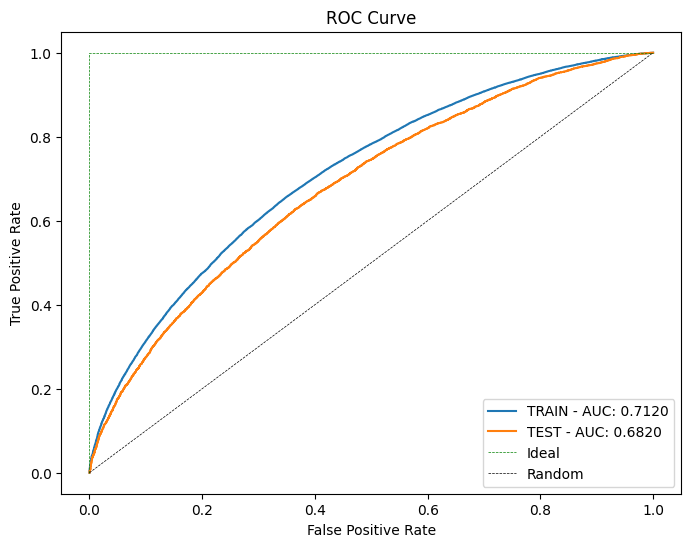

In [38]:
#Plot
plt.figure(figsize=[8,6])
plt.plot(fpr_train, tpr_train, label='TRAIN - AUC: {:.4f}'.format(auc_train))
plt.plot(fpr_test, tpr_test, label='TEST - AUC: {:.4f}'.format(auc_test))
plt.title('ROC Curve')
plt.plot([0,0,1],[0,1,1], color='green', linestyle='--', linewidth=0.5, label='Ideal')
plt.plot([0, 1], [0, 1], color='black', linestyle='--', linewidth=0.5, label='Random')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.legend(loc="lower right")
plt.show()

In [39]:
cm_test = confusion_matrix(y_test, y_test_pred)

[]

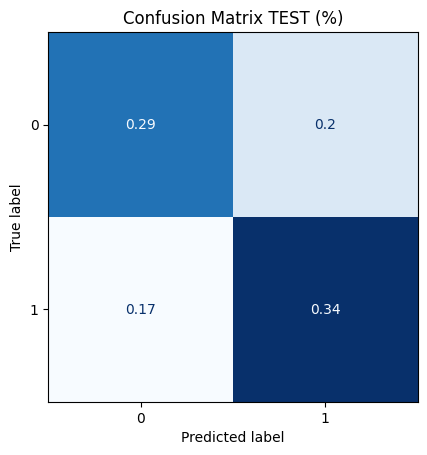

In [40]:
ConfusionMatrixDisplay(confusion_matrix=cm_test/len(y_test)).plot(colorbar = False, cmap = 'Blues')
plt.title('Confusion Matrix TEST (%)')
plt.plot()

In [41]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

print('Accuracy:', format(round( accuracy_score(y_test, y_test_pred),4),'0.2%'))
print('Precision:', format(round( precision_score(y_test, y_test_pred), 4), '0.2%'))
print('Recall:', format(round( recall_score(y_test, y_test_pred), 4), '0.2%'))
print('F1-score:', format(round(f1_score(y_test, y_test_pred), 4), '0.2%'))

Accuracy: 62.96%
Precision: 63.04%
Recall: 65.86%
F1-score: 64.42%


# INTERPRETABILITY

* Analizamos top features del modelo y su peso en el modelo.
* Plotear SHAP values y el impacto positivo/negativo.
* Comentar las top5 features, su impacto en el target y extraer insights.
* Analisis complementarios:
  * Modelos de arboles: Feature Importances, plot de arbol de decision.
  * Modelos lineales: Coeficentes y formula del modelo.

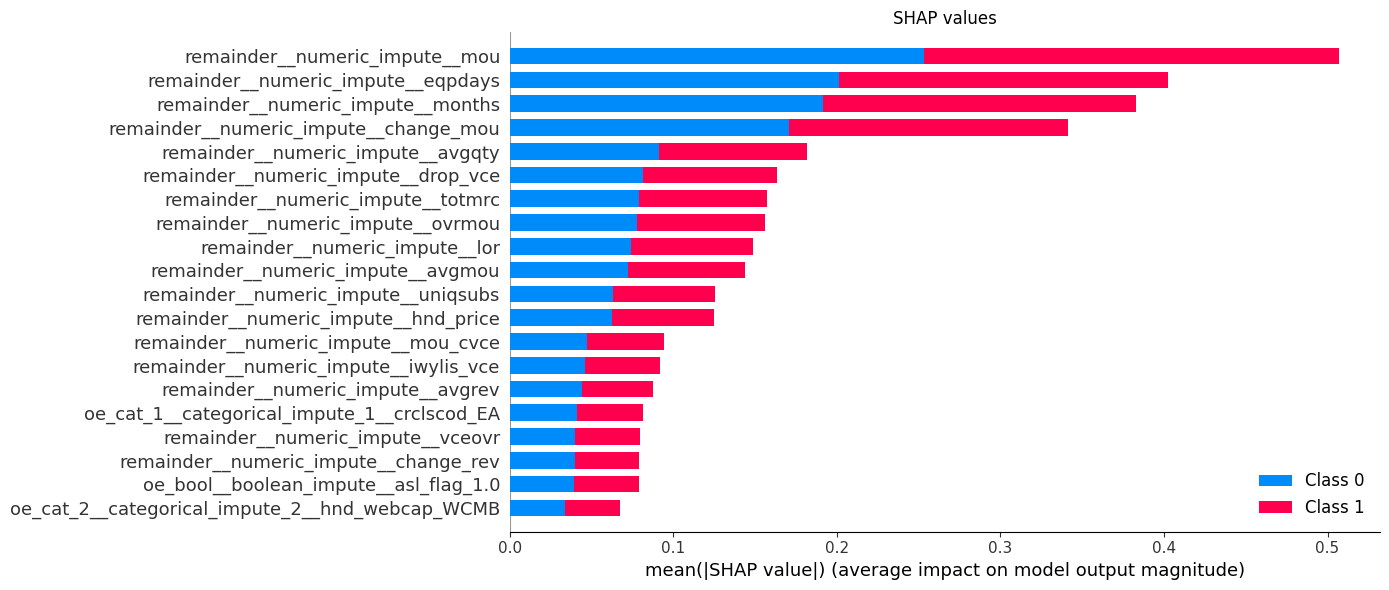

In [49]:
#SHAP value: peso en el output final

explainer = shap.TreeExplainer(model)
shap_values = explainer.shap_values(X_test)
plt.title('SHAP values')
shap.summary_plot(shap_values, X_test, plot_type="bar", max_display=20, plot_size=[14,6])

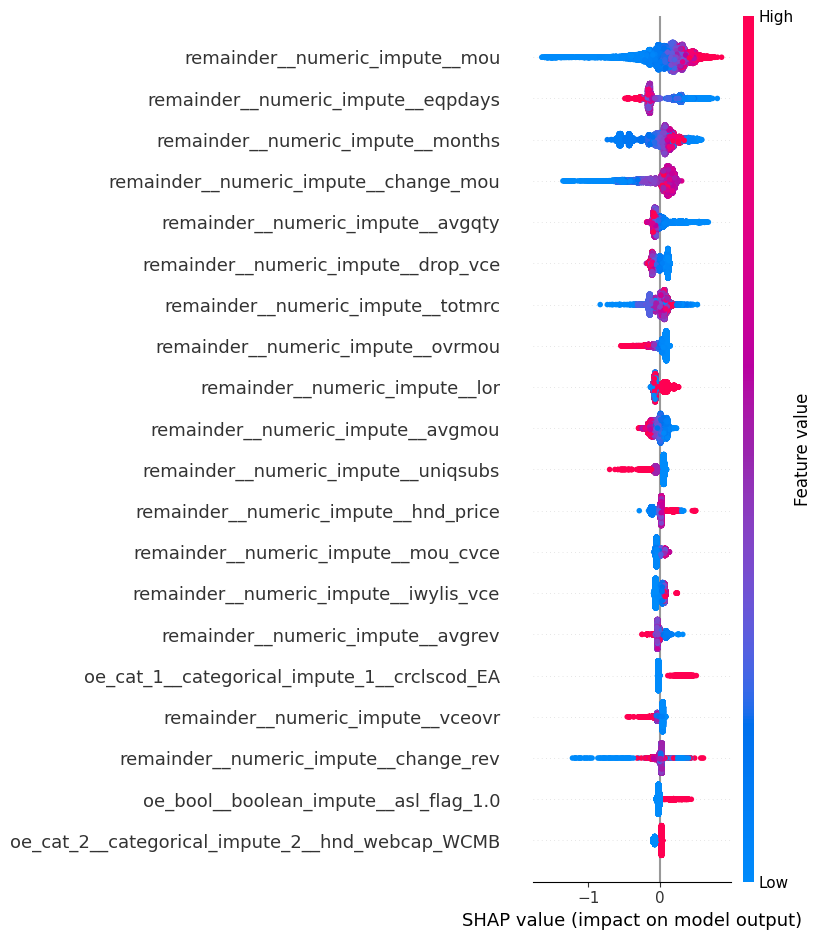

In [50]:
# impacto en churn en mes + 1 = 0 (no churn)
# shap_values[0]

shap.summary_plot(shap_values[0], X_test, show = False)

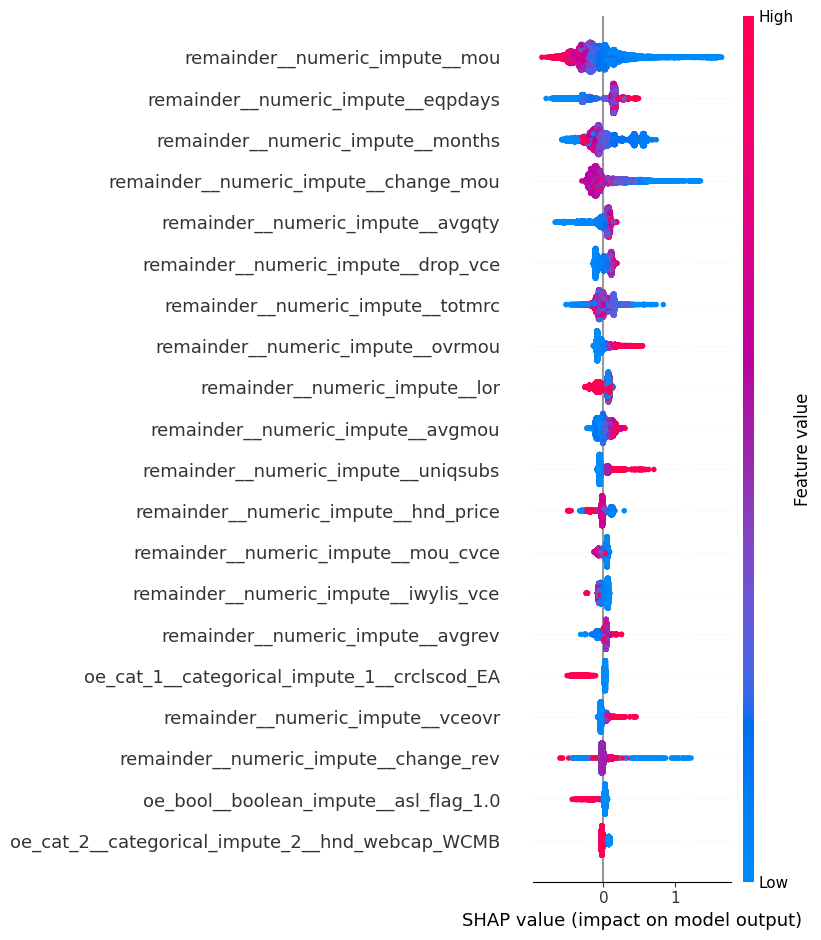

In [51]:
# impacto en churn en mes + 1 = 1 (churn)
# shap_values[1]

shap.summary_plot(shap_values[1], X_test, show = False)

Comentarios sobre las top features:


1. un mayor eqpdays impacta en el churn, la logica aquí puede ser que al tener un equipo con más antiguedad y querer cambiarlo por uno más moderno, uno acuda a una oferta de otra empreser por un motivo como puede ser el financiamiento por ejemplo

2. un menor number of months impacta en el churn ya que ante un menor numero de meses en el servicio uno no tiene ataduras con la empresa ni aun está familiriazido con la forma de operar. Todo cambio siempre lleva asociado un coste (que no siempre es monetario), y ese coste suele ser mayor cuanto más tiempo se pasa en una empresa

3. un menor mou impacta en el churn ya que un menor uso de minutos de la línea va a ser que sea más propenso que una persona se de de baja del servicio (dependera del tipo de tarifa obviamente pero si paga un fijo y no lo usa no tiene sentido seguir pagando el servicio)

4. un change_mou negativo (como vimos que tiene esta variable) impacta en el churn ya que si el valor es negativo indica que el uso de minutos esta disminuyendo, y ante un menor uso vemos el mismo impacto que en la variable mou (punto 3)

5. para totmrc vemos un impacto en el churn para valores más, podemos inferir (al igual que en el punto 3 y 4) que un cargo bajo demuestra un poco uso del servicio por lo que sería lógico darse de baja. Son métricas que nos demuestran cuanto se usa el servicio